# Customer Churn Prediction
**Workflow:** Setup → EDA → Data Cleaning → Feature Engineering → Model Building → Evaluation








---



step 1 -- Setup & Load data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score,roc_curve
from sklearn.preprocessing import RobustScaler

In [ ]:
# Load dataset
df = pd.read_csv("/content/customer_churn_dataset-testing-master.csv")

In [ ]:
print(f'Dataset shape: {df.shape}')

Dataset shape: (64374, 12)


In [ ]:
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   CustomerID         64374 non-null  int64 
 1   Age                64374 non-null  int64 
 2   Gender             64374 non-null  object
 3   Tenure             64374 non-null  int64 
 4   Usage Frequency    64374 non-null  int64 
 5   Support Calls      64374 non-null  int64 
 6   Payment Delay      64374 non-null  int64 
 7   Subscription Type  64374 non-null  object
 8   Contract Length    64374 non-null  object
 9   Total Spend        64374 non-null  int64 
 10  Last Interaction   64374 non-null  int64 
 11  Churn              64374 non-null  int64 
dtypes: int64(9), object(3)
memory usage: 5.9+ MB


In [ ]:
df.describe()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000
mean,32187.500000,41.970982,31.994827,15.080234,5.400690,17.133952,541.023379,15.498850,0.473685
std,18583.317451,13.924911,17.098234,8.816470,3.114005,8.852211,260.874809,8.638436,0.499311
min,1.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,16094.250000,30.000000,18.000000,7.000000,3.000000,10.000000,313.000000,8.000000,0.000000
50%,32187.500000,42.000000,33.000000,15.000000,6.000000,19.000000,534.000000,15.000000,0.000000
75%,48280.750000,54.000000,47.000000,23.000000,8.000000,25.000000,768.000000,23.000000,1.000000
max,64374.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


##step 2 - Exploratory Data Analysis (EDA)

### 2.1 — Churn Rate Distribution

In [ ]:
count_churn = df["Churn"].value_counts()
count_churn

,count
Churn,
0,33881
1,30493


In [ ]:
churn_rate = df['Churn'].mean() * 100
print(f'churn_rate: {churn_rate:.2f}%')

churn_rate: 47.37%


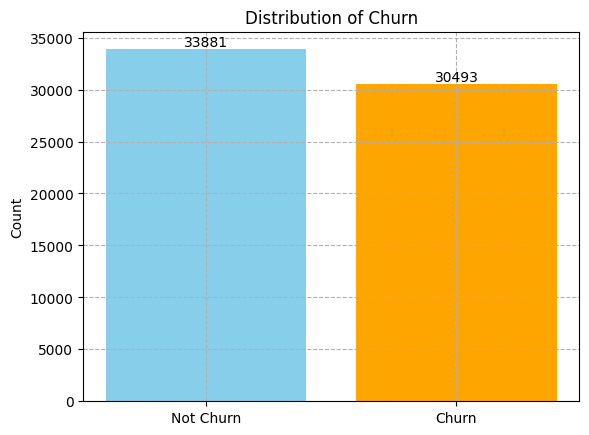

In [ ]:
Distribution_of_Churn = plt.bar(x=[0,1], height=count_churn, color=['skyblue','orange'])
plt.xticks([0,1], ["Not Churn", "Churn"])
plt.ylabel("Count")
plt.bar_label(Distribution_of_Churn)
plt.title("Distribution of Churn")
plt.grid(True, linestyle = "--")
plt.show()

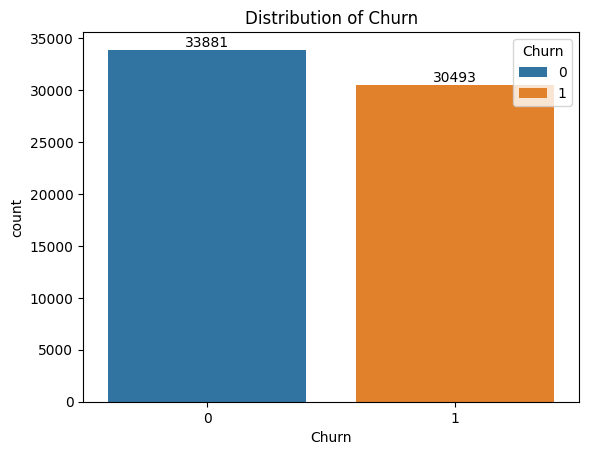

In [ ]:
# Other method

Distribution_of_Churn = sns.countplot(data= df, x='Churn', hue="Churn")
for i in Distribution_of_Churn.containers:
    Distribution_of_Churn.bar_label(i)
plt.title("Distribution of Churn")
plt.show()

2.2 — Histogram plots (distribution of each numeric column)

In [ ]:
cols_to_plot1 = df.select_dtypes(include=np.number).columns
cols_to_plot1

Index(['CustomerID', 'Age', 'Tenure', 'Usage Frequency', 'Support Calls',
       'Payment Delay', 'Total Spend', 'Last Interaction', 'Churn'],
      dtype='object')

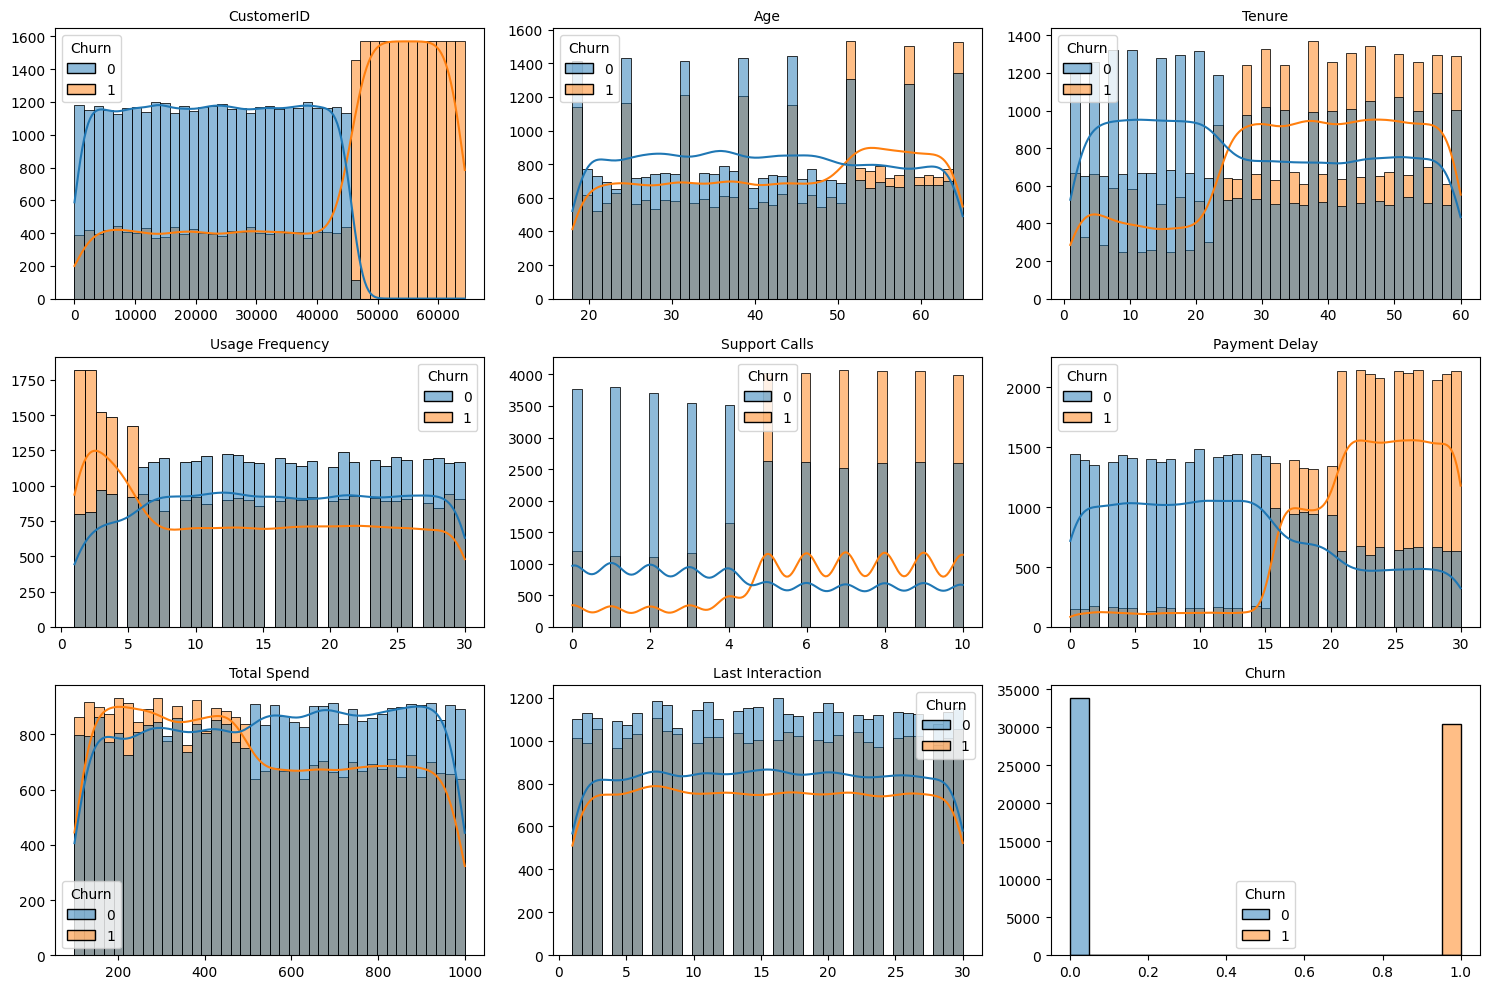

In [ ]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 10))
axes = axes.flatten()
for i, col in enumerate(cols_to_plot1):
    sns.histplot(data=df, x=col,hue="Churn", kde=True, ax=axes[i]) # we can also use ax = axes[i//3, i%3] and their is no need to use flatten.

    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('') # Clean up the bottom label to save space
    axes[i].set_ylabel('') # Clean up the left label to save space

# Fix the "Squashed" look
plt.tight_layout()
plt.show()

2.3 — Box plots (churned vs stayed comparison)

In [ ]:
cols_to_plot2 = df.select_dtypes(include=np.number).columns.drop("Churn")
cols_to_plot2

Index(['CustomerID', 'Age', 'Tenure', 'Usage Frequency', 'Support Calls',
       'Payment Delay', 'Total Spend', 'Last Interaction'],
      dtype='object')

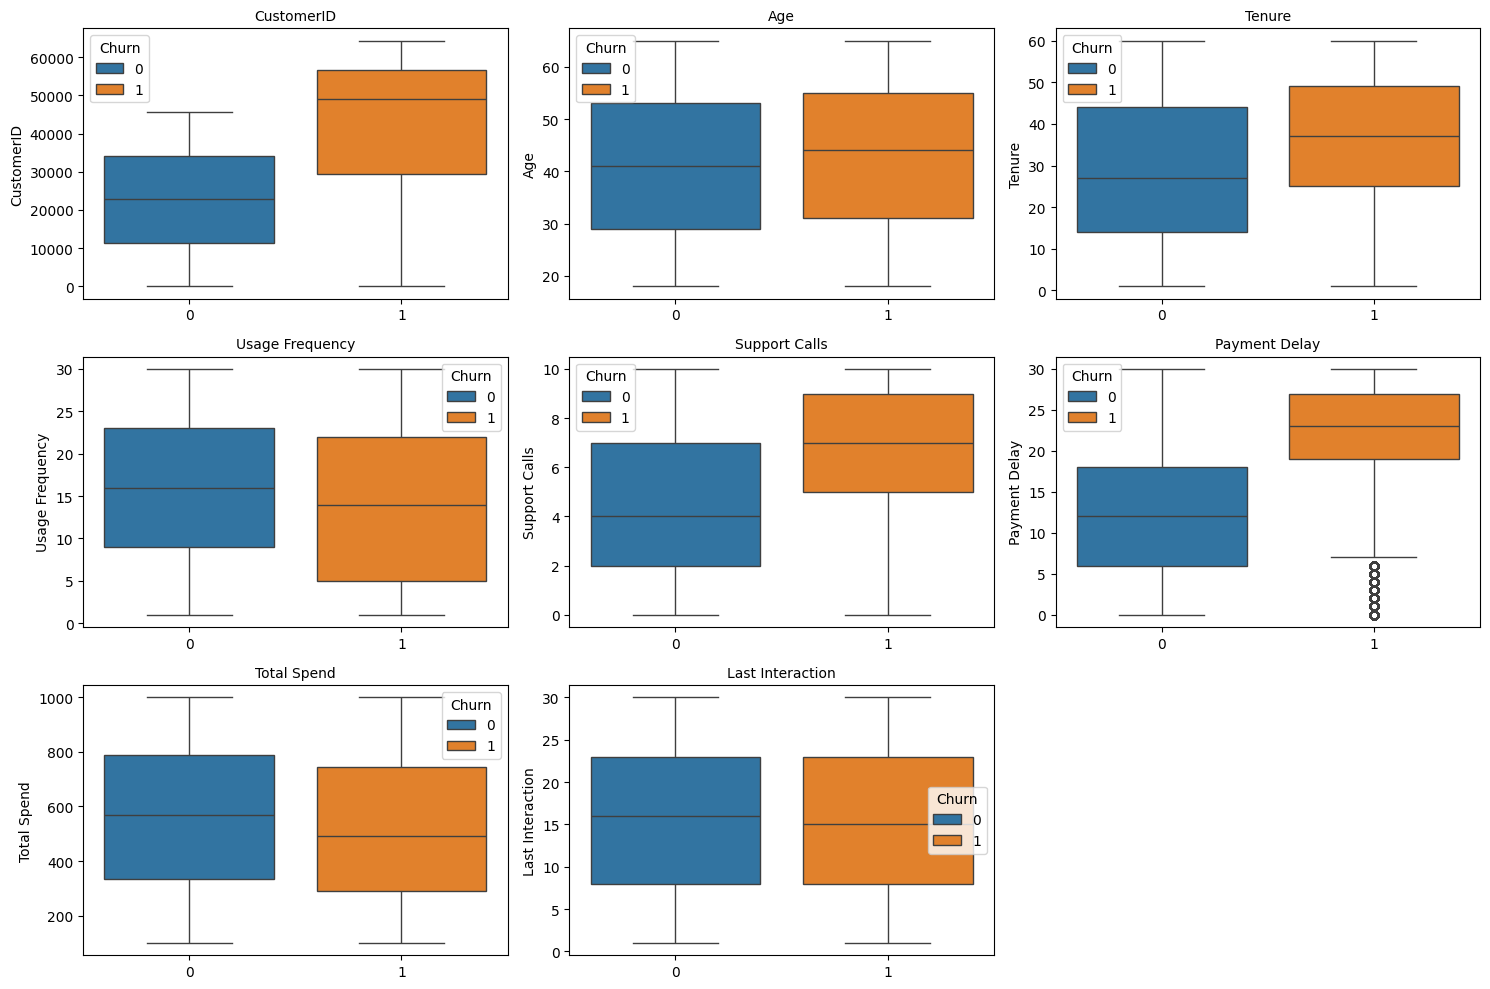

In [ ]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 10))
axes = axes.flatten()
for i, col in enumerate(cols_to_plot2):
    sns.boxplot(data=df, x="Churn",hue="Churn", y=col, ax=axes[i])

    # Add a title to each small box
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('') # Clean up the bottom label to save space

# (Extra axes beyond the number of columns are hidden to keep the layout clean.)
for j in range(len(cols_to_plot2), len(axes)):
    axes[j].set_axis_off()

# Fix the "Squashed" look
plt.tight_layout()
plt.show()

2.4 Stacked bar (stayed vs churned side by side per category)

In [ ]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
cat_cols

['Gender', 'Subscription Type', 'Contract Length']

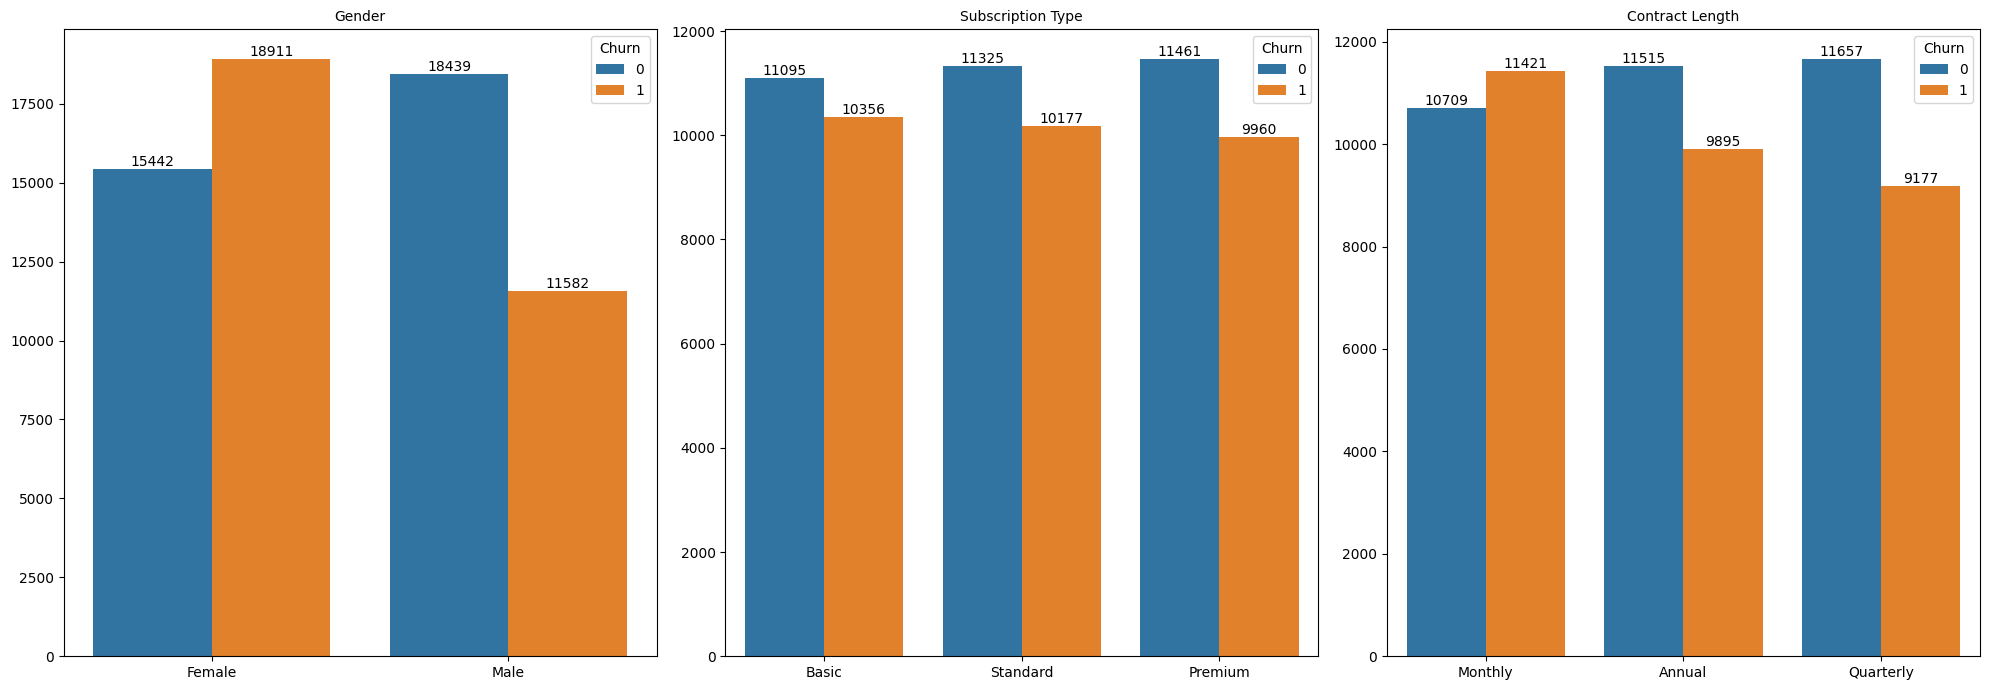

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 7))
axes = axes.flatten()
for i,col in enumerate(cat_cols):
    bar=sns.countplot(data=df, x=col, hue="Churn", ax=axes[i])
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
    for j in bar.containers:
      bar.bar_label(j)

plt.tight_layout()
plt.show()

2.5 Correlation heatmap


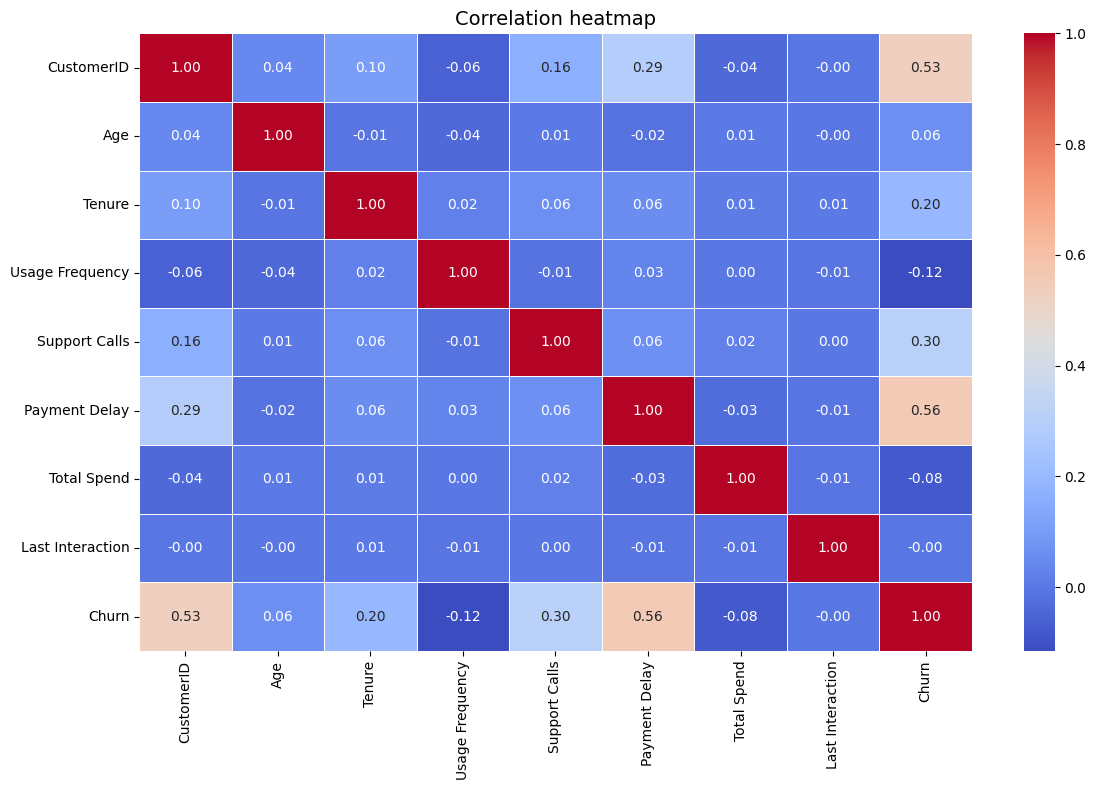

In [ ]:
plt.figure(figsize=(12, 8))

num_df = df.select_dtypes(include=np.number)
corr_matrix = num_df.corr()

sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            linewidths=0.5)

plt.title('Correlation heatmap', fontsize=14)
plt.tight_layout()
plt.show()

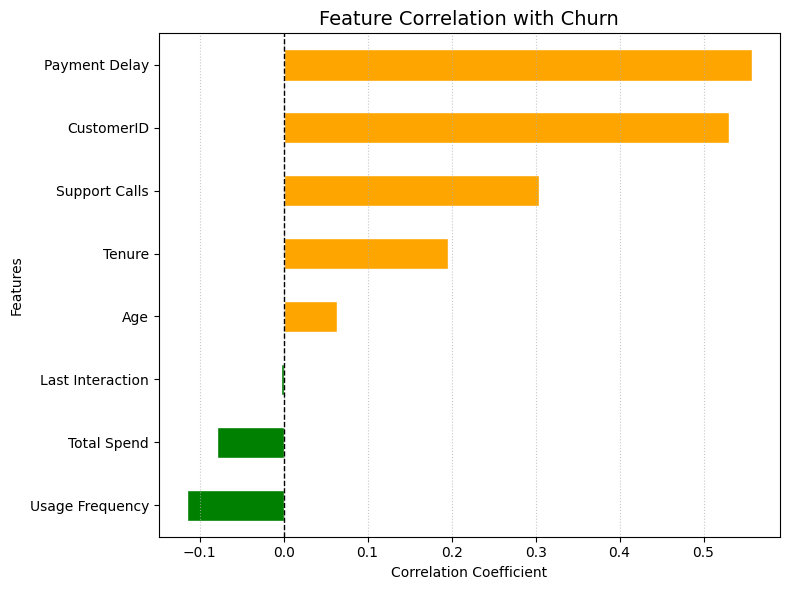


Top features correlated with churn:
Payment Delay       0.557386
CustomerID          0.529832
Support Calls       0.304631
Tenure              0.195327
Usage Frequency     0.115098
Total Spend         0.078867
Age                 0.063457
Last Interaction    0.002818
Name: Churn, dtype: float64


In [ ]:
# Feature correlation with Churn (bar chart)

# 1. Calculate how every number relates to 'Churn'
# We sort them so the bars look like a "staircase"
correlations = corr_matrix['Churn'].drop('Churn').sort_values()

# 2. Pick the colors (Orange for Positive, Green for Negative)
# Positive means: "As this goes up, Churn goes up"
# Negative means: "As this goes up, Churn goes down"
colors = ['orange' if x > 0 else 'green' for x in correlations]

# 3. Create the plot
plt.figure(figsize=(8, 6))
correlations.plot(kind='barh', color=colors, edgecolor='white')

# 4. Add the finishing touches to make it look professional
plt.axvline(0, color='black', linestyle='--', linewidth=1) # The dashed line at 0
plt.title('Feature Correlation with Churn', fontsize=14)
plt.xlabel('Correlation Coefficient')
plt.ylabel('Features')
plt.grid(axis='x', linestyle=':', alpha=0.7) # Adds faint vertical dots for easier reading

plt.tight_layout()
plt.show()

print("\nTop features correlated with churn:")
print(correlations.abs().sort_values(ascending=False))

step 3 -- Data Cleaning

In [ ]:
# Check for missing values
print('Missing values per column:')
df.isnull().sum()

Missing values per column:


,0
CustomerID,0
Age,0
Gender,0
Tenure,0
Usage Frequency,0
Support Calls,0
Payment Delay,0
Subscription Type,0
Contract Length,0
Total Spend,0


In [ ]:
# Check for duplicates
print(f'Duplicate rows: {df.duplicated().sum()}')

Duplicate rows: 0


In [ ]:
# Drop CustomerID — not a predictive feature
df.drop(columns=['CustomerID'], inplace=True)
print(f'Shape after dropping CustomerID: {df.shape}')

Shape after dropping CustomerID: (64374, 11)


step 4 -- Feature Engineering

In [ ]:
# Encode categorical columns using ordinal mapping
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})
df['Subscription Type'] = df['Subscription Type'].map({'Basic': 0, 'Standard': 1, 'Premium': 2})
df['Contract Length'] = df['Contract Length'].map({'Monthly': 0, 'Quarterly': 1, 'Annual': 2})

In [ ]:
df[['Gender','Subscription Type','Contract Length']].head()

,Gender,Subscription Type,Contract Length
0,0,0,0
1,0,1,0
2,1,2,2
3,1,2,1
4,0,1,2


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Age                64374 non-null  int64
 1   Gender             64374 non-null  int64
 2   Tenure             64374 non-null  int64
 3   Usage Frequency    64374 non-null  int64
 4   Support Calls      64374 non-null  int64
 5   Payment Delay      64374 non-null  int64
 6   Subscription Type  64374 non-null  int64
 7   Contract Length    64374 non-null  int64
 8   Total Spend        64374 non-null  int64
 9   Last Interaction   64374 non-null  int64
 10  Churn              64374 non-null  int64
dtypes: int64(11)
memory usage: 5.4 MB


step 5 -- Model Building

### 5.1 — Train/Test Split

In [ ]:
x = df.drop(columns=['Churn'])
y = df['Churn']

In [ ]:
x.head(2)

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction
0,22,0,25,14,4,27,0,0,598,9
1,41,0,28,28,7,13,1,0,584,20


In [ ]:
y.head(2)

,Churn
0,1
1,0


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
print(f"Shape of x_train: {x_train.shape}")
print(f"Shape of y_train: {y_train.shape}")

Shape of x_train: (51499, 10)
Shape of y_train: (51499,)


In [ ]:
print(f"Shape of x_test: {x_test.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of x_test: (12875, 10)
Shape of y_test: (12875,)


### 5.2 — Scale Features (after split to prevent data leakage)

In [ ]:
scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(x_train)
X_test_scaled = scaler.transform(x_test)

### 5.3 — Train Models

In [ ]:
# Logistic Regression
lr = LogisticRegression(random_state=42)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

In [ ]:
# Decision Tree
dtree = DecisionTreeClassifier(criterion='entropy', random_state=42)

param_grid = {
    'max_depth': [3, 4, 5],
    'min_samples_split': [10, 20],
    'min_samples_leaf': [5, 10]
}

grid = GridSearchCV(dtree, param_grid, cv=5, scoring='recall')
grid.fit(x_train, y_train)

best_tree = grid.best_estimator_
y_pred_tree = best_tree.predict(x_test)

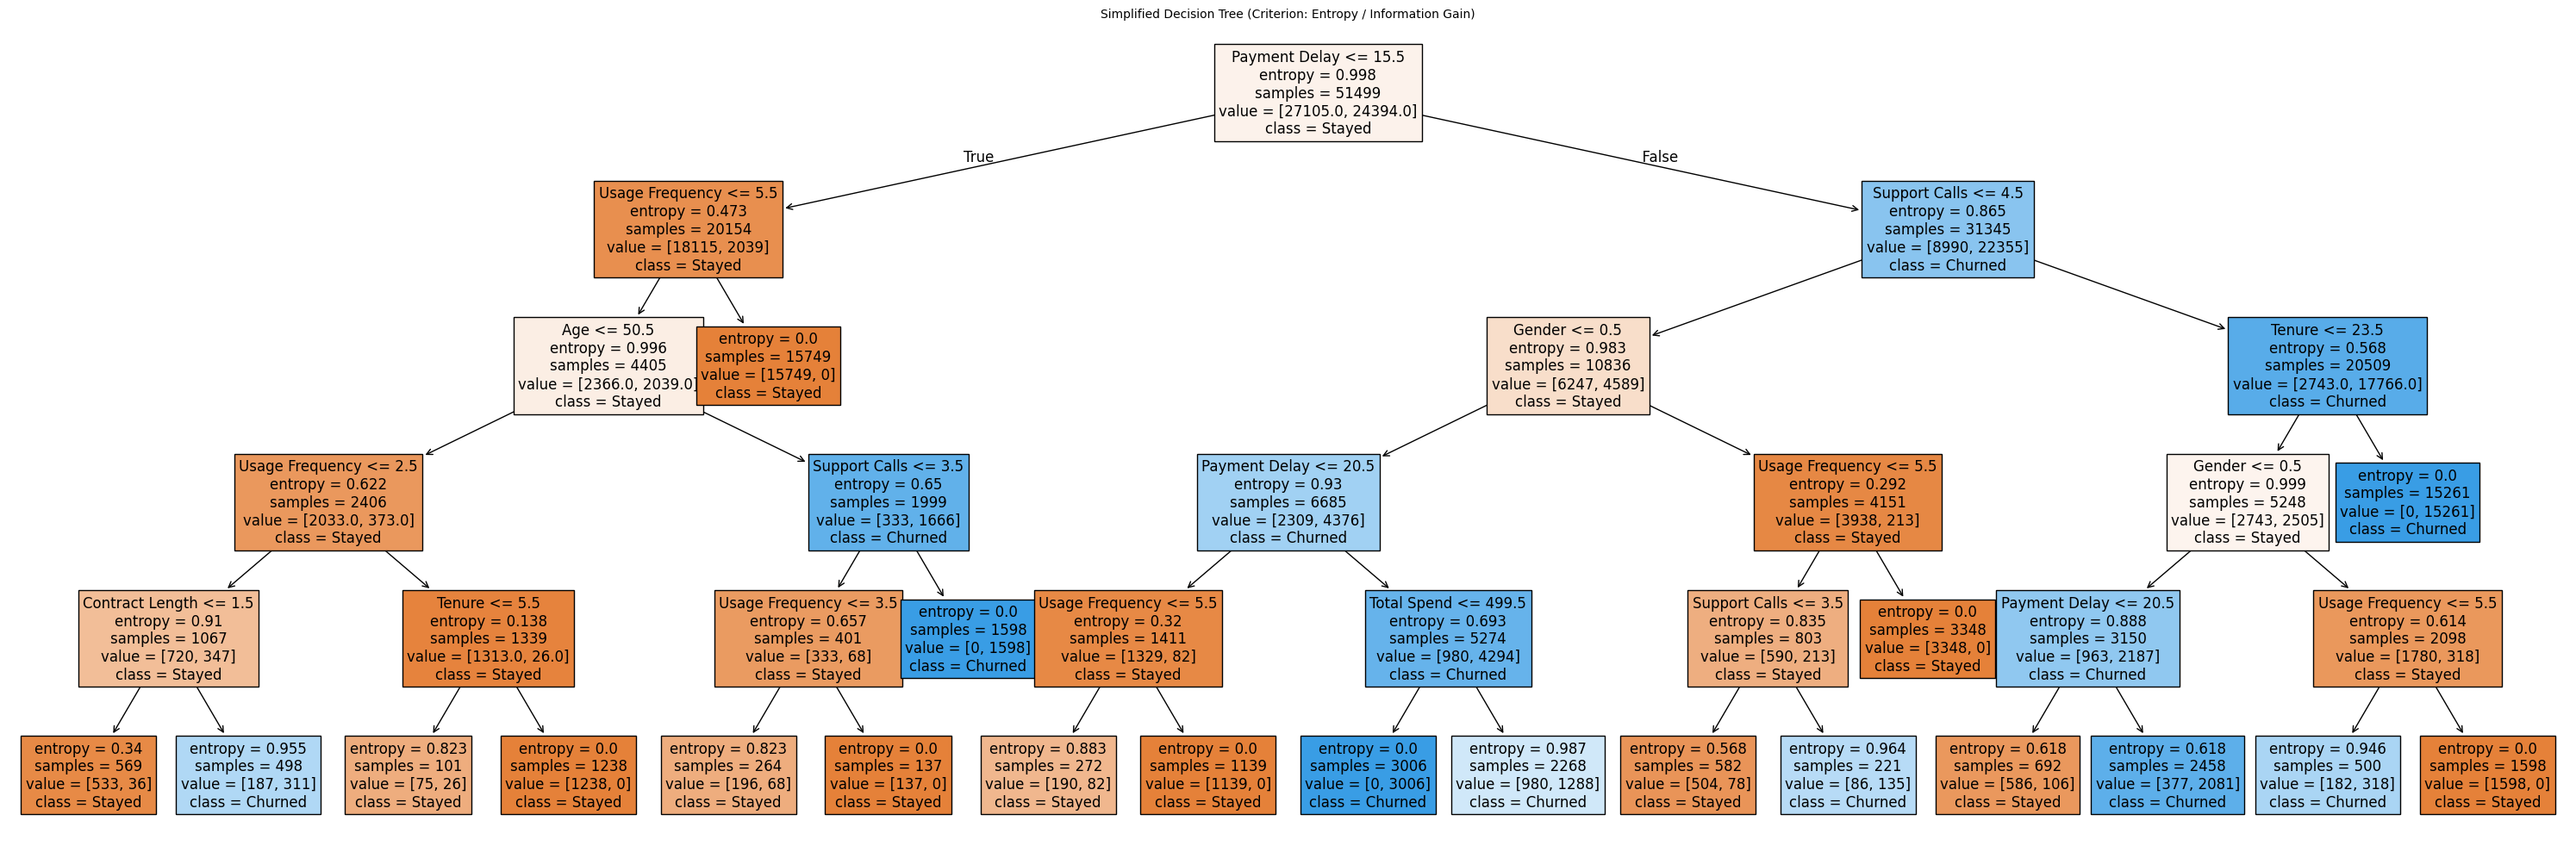

In [ ]:
# Decision Tree Visualization (80/20 Split)
plt.figure(figsize=(30,10))
tree_plot = plot_tree(best_tree,
          feature_names=x.columns,
          class_names=['Stayed', 'Churned'],
          filled=True,
          fontsize=12)

plt.title("Simplified Decision Tree (Criterion: Entropy / Information Gain)", fontsize=10)
plt.tight_layout()
plt.show()

---
## Step 6 — Model Evaluation

### 6.1 — Classification Reports

In [ ]:
# EVALUATION & FINAL VISUALS ---
print("Logistic Regression Report:\n", classification_report(y_test, y_pred_lr))
print("Decision Tree Report:\n", classification_report(y_test, y_pred_tree))

Logistic Regression Report:
               precision    recall  f1-score   support

           0       0.84      0.83      0.83      6776
           1       0.81      0.82      0.82      6099

    accuracy                           0.83     12875
   macro avg       0.82      0.83      0.83     12875
weighted avg       0.83      0.83      0.83     12875

Decision Tree Report:
               precision    recall  f1-score   support

           0       0.98      0.93      0.96      6776
           1       0.93      0.98      0.95      6099

    accuracy                           0.96     12875
   macro avg       0.96      0.96      0.96     12875
weighted avg       0.96      0.96      0.96     12875



### 6.2 — Confusion Matrices

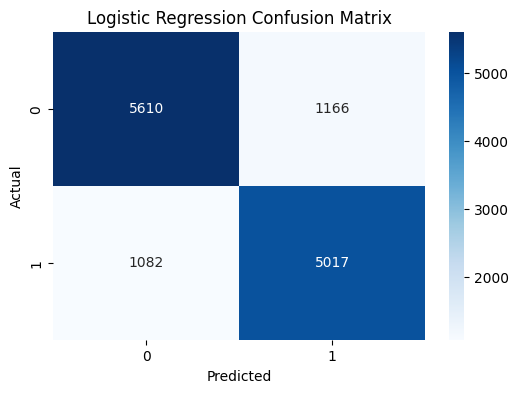

In [ ]:
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues')
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

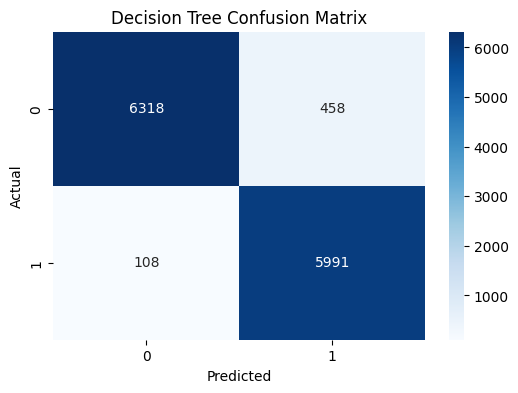

In [ ]:
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_tree), annot=True, fmt='d', cmap='Blues')
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### 6.3 — ROC-AUC Curves

In [ ]:
# 1. Get predicted probabilities for the positive class (column 1)
y_probs_lr = lr.predict_proba(X_test_scaled)[:, 1]
y_probs_tree = best_tree.predict_proba(x_test)[:, 1]

# 2. Calculate AUC Score
auc_score_lr = roc_auc_score(y_test, y_probs_lr)
print(f"AUC Score: {auc_score_lr:.4f}")

auc_score_tree = roc_auc_score(y_test, y_probs_tree)
print(f"AUC Score: {auc_score_tree:.4f}")

# 3. Get FPR and TPR values for the curve
fpr, tpr, thresholds = roc_curve(y_test, y_probs_lr)
fpr_tree, tpr_tree, thresholds_tree = roc_curve(y_test, y_probs_tree)

AUC Score: 0.9023
AUC Score: 0.9940


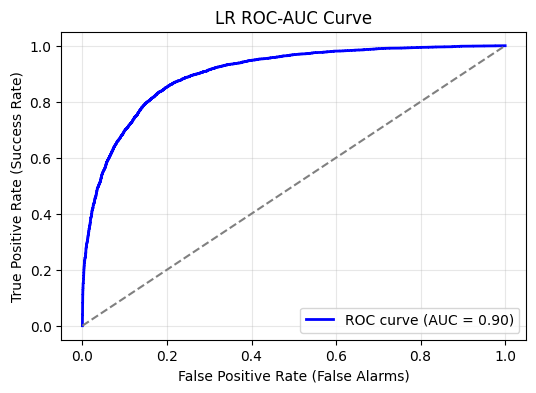

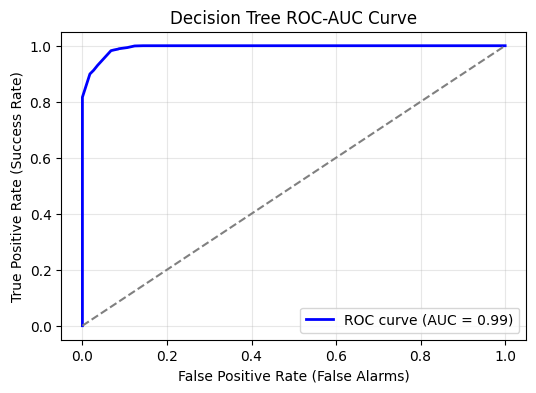

In [ ]:
# Plotting the result
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {auc_score_lr:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # The "Random Guess" line
plt.xlabel('False Positive Rate (False Alarms)')
plt.ylabel('True Positive Rate (Success Rate)')
plt.title('LR ROC-AUC Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(fpr_tree, tpr_tree, color='blue', lw=2, label=f'ROC curve (AUC = {auc_score_tree:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # The "Random Guess" line
plt.xlabel('False Positive Rate (False Alarms)')
plt.ylabel('True Positive Rate (Success Rate)')
plt.title('Decision Tree ROC-AUC Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# Step 7 — Export predictions for Power BI

# 1. Take the original test data (unscaled, readable)
export_df = x_test.copy()

In [ ]:
# 2. Reverse the encoding — convert numbers back to readable labels
export_df['Gender'] = export_df['Gender'].map({1: 'Male', 0: 'Female'})
export_df['Subscription Type'] = export_df['Subscription Type'].map({0: 'Basic', 1: 'Standard', 2: 'Premium'})
export_df['Contract Length'] = export_df['Contract Length'].map({0: 'Monthly', 1: 'Quarterly', 2: 'Annual'})

In [ ]:
# 2. Add actual and predicted churn columns
export_df['Actual_Churn'] = y_test.values
export_df['Predicted_Churn'] = y_pred_tree  # ✅ Only Decision Tree

In [ ]:
# 3. Add churn risk probability
export_df['Churn_Risk_Score'] = y_probs_tree  # ✅ Decision Tree probabilities

In [ ]:
# 4. Label risk segments
def risk_label(score):
    if score >= 0.7:
        return 'High Risk'
    elif score >= 0.4:
        return 'Medium Risk'
    else:
        return 'Low Risk'

export_df['Risk_Segment'] = export_df['Churn_Risk_Score'].apply(risk_label)

In [ ]:
# 5. Save it
export_df.to_csv('churn_predictions.csv', index=False)
print("✅ Exported! Shape:", export_df.shape)

✅ Exported! Shape: (12875, 14)
